# Model Training & Deployment — Pharma Sales Forecasting
---
**Models:** XGBoost and Random Forest regressors with hyperparameter tuning.

**Evaluation:** RMSE, MAE, R²

**Deployment:** FastAPI endpoint for real-time predictions.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Config
DATA_DIR  = Path("processed_data")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

TARGET_COL = "N02BE"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

print("Setup complete ✓")

Setup complete ✓


## 2. Load Processed Data

In [2]:
# Load train/test and feature list from feature_engineering pipeline
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["datum"])
test  = pd.read_csv(DATA_DIR / "test.csv",  parse_dates=["datum"])
feature_cols = joblib.load(DATA_DIR / "feature_columns.joblib")

X_train = train[feature_cols]
y_train = train[TARGET_COL]
X_test  = test[feature_cols]
y_test  = test[TARGET_COL]

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Features: {len(feature_cols)}")

Train: 46 samples
Test:  12 samples
Features: 38


## 3. Helper: Evaluation Function

In [3]:
def evaluate_model(y_true, y_pred, model_name):
    """Compute and display RMSE, MAE, R²."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*40}")

    return {"RMSE": rmse, "MAE": mae, "R2": r2}

## 4. Train XGBoost (with Hyperparameter Tuning)

In [4]:
# Hyperparameter search space
xgb_param_dist = {
    "n_estimators":    [100, 200, 300, 500],
    "max_depth":       [3, 5, 7, 9],
    "learning_rate":   [0.01, 0.05, 0.1, 0.2],
    "subsample":       [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.6, 0.8, 1.0],
    "reg_alpha":       [0, 0.1, 1.0],
    "reg_lambda":      [1.0, 2.0, 5.0],
}

xgb_base = XGBRegressor(objective="reg:squarederror", random_state=42, verbosity=0)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

print("Tuning XGBoost (30 iterations, 3-fold CV) …")
xgb_search.fit(X_train, y_train)

xgb_model = xgb_search.best_estimator_
print(f"\nBest parameters:\n{xgb_search.best_params_}")

Tuning XGBoost (30 iterations, 3-fold CV) …

Best parameters:
{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [5]:
# Evaluate XGBoost on test set
xgb_preds = xgb_model.predict(X_test)
xgb_metrics = evaluate_model(y_test, xgb_preds, "XGBoost")


  XGBoost
  RMSE : 87.9027
  MAE  : 54.3750
  R²   : 0.9355


## 5. Train Random Forest (with Hyperparameter Tuning)

In [6]:
# Hyperparameter search space
rf_param_dist = {
    "n_estimators":    [100, 200, 300, 500],
    "max_depth":       [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.5, 0.8],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

print("Tuning Random Forest (30 iterations, 3-fold CV) …")
rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
print(f"\nBest parameters:\n{rf_search.best_params_}")

Tuning Random Forest (30 iterations, 3-fold CV) …

Best parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}


In [7]:
# Evaluate Random Forest on test set
rf_preds = rf_model.predict(X_test)
rf_metrics = evaluate_model(y_test, rf_preds, "Random Forest")


  Random Forest
  RMSE : 117.7980
  MAE  : 68.6194
  R²   : 0.8842


## 6. Model Comparison

In [8]:
# Side-by-side comparison
results = {"XGBoost": xgb_metrics, "Random Forest": rf_metrics}
comparison = pd.DataFrame(results).T
comparison.style.highlight_min(subset=["RMSE", "MAE"], color="lightgreen") \
               .highlight_max(subset=["R2"], color="lightgreen")

,RMSE,MAE,R2
XGBoost,87.902744,54.375006,0.935516
Random Forest,117.797962,68.619414,0.884196


In [9]:
# Pick the best model by R²
best_name = comparison["R2"].idxmax()
best_model = xgb_model if best_name == "XGBoost" else rf_model
print(f"🏆 Best model: {best_name} (R² = {comparison.loc[best_name, 'R2']:.4f})")

🏆 Best model: XGBoost (R² = 0.9355)


## 7. Feature Importance

In [10]:
def plot_feature_importance(model, feature_names, model_name, top_n=15):
    """Horizontal bar chart of top feature importances."""
    importances = model.feature_importances_
    idx = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh([feature_names[i] for i in idx], importances[idx], color="steelblue")
    ax.set_title(f"Top {top_n} Feature Importances — {model_name}", fontsize=13)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

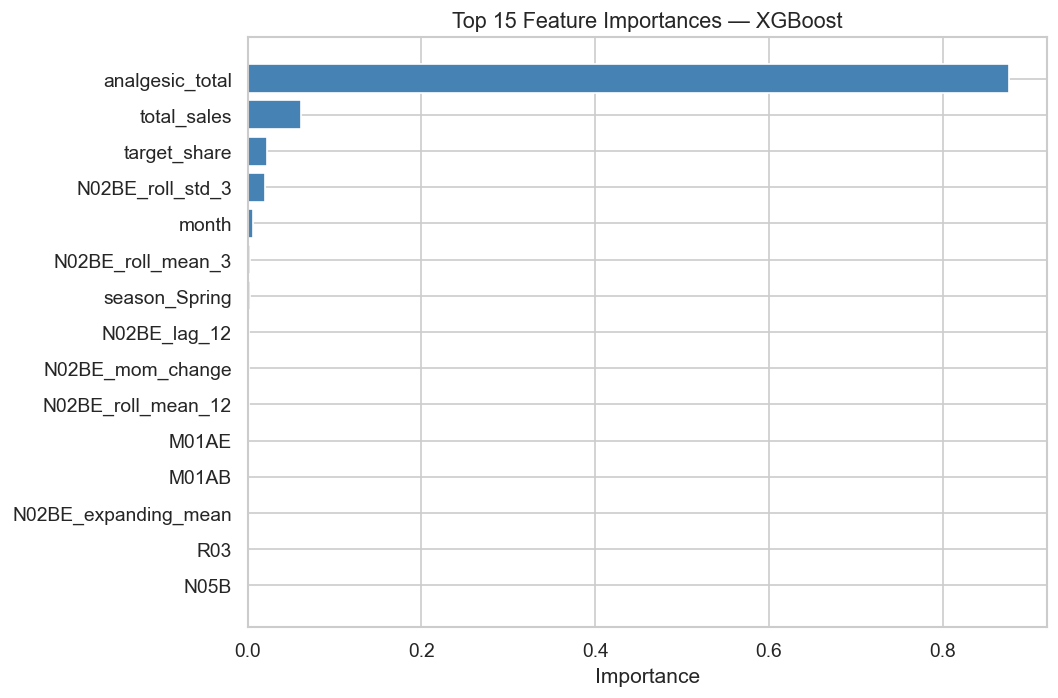

In [11]:
plot_feature_importance(xgb_model, feature_cols, "XGBoost")

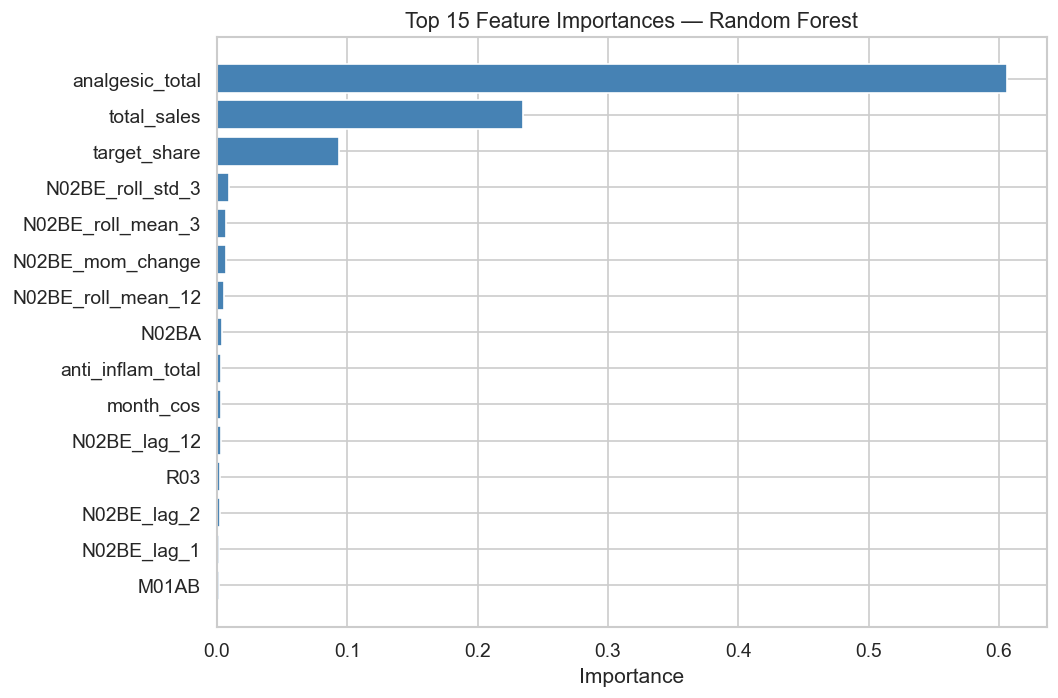

In [12]:
plot_feature_importance(rf_model, feature_cols, "Random Forest")

## 8. Actual vs. Predicted

In [13]:
def plot_actual_vs_predicted(y_true, y_pred, dates, model_name):
    """Time-series overlay of actual vs predicted."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(dates.values, y_true, label="Actual", marker="o", linewidth=1.5)
    ax.plot(dates.values, y_pred, label="Predicted", marker="x",
            linewidth=1.5, linestyle="--")
    ax.set_title(f"Actual vs Predicted ({TARGET_COL}) — {model_name}", fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()
    plt.tight_layout()
    plt.show()

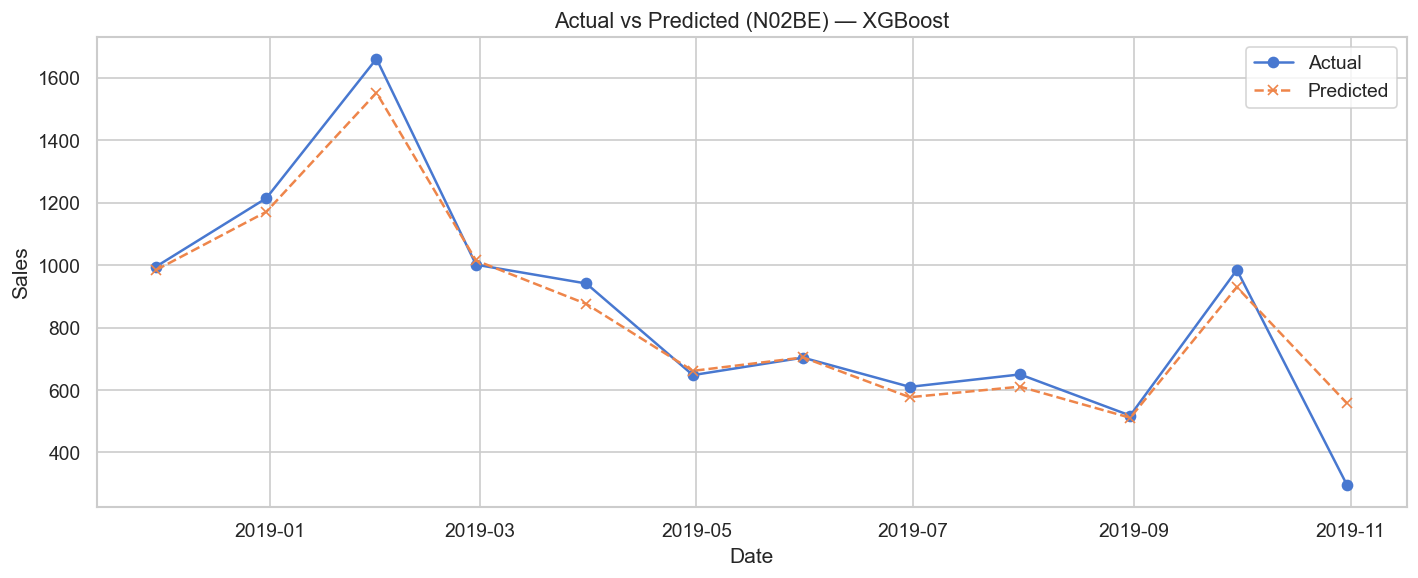

In [14]:
plot_actual_vs_predicted(y_test.values, xgb_preds, test["datum"], "XGBoost")

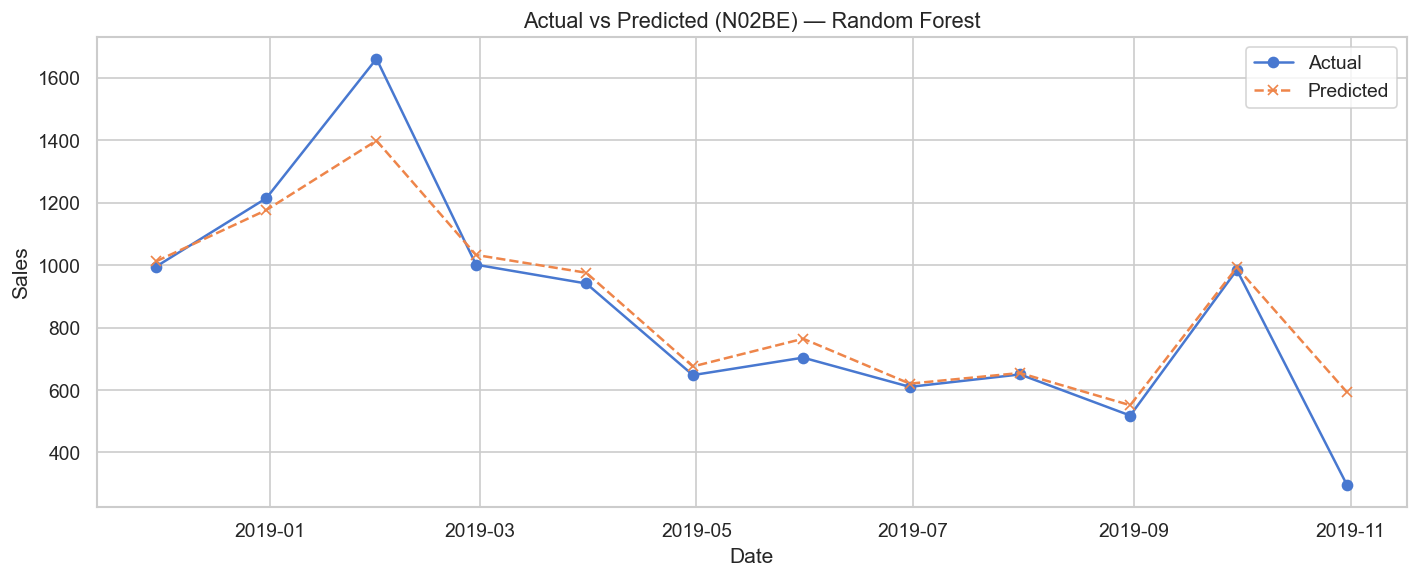

In [15]:
plot_actual_vs_predicted(y_test.values, rf_preds, test["datum"], "Random Forest")

## 9. Save Trained Models

In [16]:
# Save all models
joblib.dump(best_model, MODEL_DIR / "best_model.joblib")
joblib.dump(xgb_model,  MODEL_DIR / "xgboost.joblib")
joblib.dump(rf_model,   MODEL_DIR / "random_forest.joblib")

# Save comparison table
comparison.to_csv(MODEL_DIR / "model_comparison.csv")

print(f"✓ Saved best_model.joblib    ({best_name})")
print(f"✓ Saved xgboost.joblib")
print(f"✓ Saved random_forest.joblib")
print(f"✓ Saved model_comparison.csv")

✓ Saved best_model.joblib    (XGBoost)
✓ Saved xgboost.joblib
✓ Saved random_forest.joblib
✓ Saved model_comparison.csv


## 10. FastAPI Deployment

Save the cell below as `app.py` and run:
```bash
uvicorn app:app --host 0.0.0.0 --port 8000 --reload
```

In [19]:

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from fastapi import FastAPI
from pydantic import BaseModel, Field

# --- Config ---
DATA_DIR  = Path("processed_data")
MODEL_DIR = Path("models")
TARGET_COL = "N02BE"

# --- App ---
app = FastAPI(
    title="Pharma Sales Forecasting API",
    description="Predict pharmaceutical drug demand using trained ML models.",
    version="1.0.0",
)

# --- Schemas ---
class PredictionRequest(BaseModel):
    drug_name: str = Field(..., example="N02BE", description="ATC drug category code")
    category: str = Field(..., example="Analgesics", description="Therapeutic category")
    month: int = Field(..., ge=1, le=12, example=10)
    previous_sales: float = Field(..., ge=0, example=1100.0)

class PredictionResponse(BaseModel):
    predicted_sales: float
    model: str
    drug_name: str
    month: int
    confidence_note: str

# --- Model loader (cached) ---
_cache = {}

def get_model():
    if "model" not in _cache:
        _cache["model"]    = joblib.load(MODEL_DIR / "best_model.joblib")
        _cache["scaler"]   = joblib.load(DATA_DIR / "feature_scaler.joblib")
        _cache["features"] = joblib.load(DATA_DIR / "feature_columns.joblib")
    return _cache["model"], _cache["scaler"], _cache["features"]

# --- Feature builder ---
def build_feature_vector(req, feature_cols):
    row = {col: 0.0 for col in feature_cols}
    row["month"] = req.month
    row["quarter"] = (req.month - 1) // 3 + 1
    row["month_sin"] = np.sin(2 * np.pi * req.month / 12)
    row["month_cos"] = np.cos(2 * np.pi * req.month / 12)
    row["is_year_start"] = int(req.month == 1)
    row["is_year_end"] = int(req.month == 12)

    for col_name in feature_cols:
        if "lag" in col_name or "roll_mean" in col_name or "expanding_mean" in col_name:
            row[col_name] = req.previous_sales
        if "roll_std" in col_name:
            row[col_name] = req.previous_sales * 0.1

    row["total_sales"] = req.previous_sales * 1.5
    row["target_share"] = req.previous_sales / max(row["total_sales"], 1)

    season_map = {12: "Winter", 1: "Winter", 2: "Winter",
                  3: "Spring", 4: "Spring", 5: "Spring",
                  6: "Summer", 7: "Summer", 8: "Summer",
                  9: "Autumn", 10: "Autumn", 11: "Autumn"}
    season_col = f"season_{season_map.get(req.month, 'Winter')}"
    if season_col in row:
        row[season_col] = 1

    return pd.DataFrame([row], columns=feature_cols)

# --- Endpoints ---
@app.get("/")
def root():
    return {"status": "ok", "message": "Pharma Sales Forecasting API is running."}

@app.post("/predict_sales", response_model=PredictionResponse)
def predict_sales(req: PredictionRequest):
    model, scaler, feature_cols = get_model()
    X = build_feature_vector(req, feature_cols)
    X[feature_cols] = scaler.transform(X[feature_cols])
    prediction = max(float(model.predict(X)[0]), 0.0)

    return PredictionResponse(
        predicted_sales=round(prediction, 2),
        model=type(model).__name__,
        drug_name=req.drug_name,
        month=req.month,
        confidence_note="Prediction uses approximated lag features. "
                        "For production accuracy, integrate with a live sales database.",
    )

print("FastAPI app defined ✓")
print("To serve: uvicorn app:app --host 0.0.0.0 --port 8000 --reload")

FastAPI app defined ✓
To serve: uvicorn app:app --host 0.0.0.0 --port 8000 --reload


## API Usage Example

```bash
curl -X POST http://localhost:8000/predict_sales \
  -H "Content-Type: application/json" \
  -d '{
    "drug_name": "N02BE",
    "category": "Analgesics",
    "month": 10,
    "previous_sales": 1100.0
  }'
```

Response:
```json
{
  "predicted_sales": 1234.56,
  "model": "XGBRegressor",
  "drug_name": "N02BE",
  "month": 10,
  "confidence_note": "..."
}
```

## Summary

| Step | Detail |
|------|--------|
| Models | XGBoost, Random Forest |
| Tuning | RandomizedSearchCV (30 iter, 3-fold CV) |
| Metrics | RMSE, MAE, R² |
| Best model | Selected by R² on test set |
| Deployment | FastAPI `/predict_sales` endpoint |
| Persistence | joblib for model + scaler + feature list |